# Continuous Normalizing Flows

**Learning objectives**
- Understand normalizing flows through a concrete 1D example before tackling the math
- Derive the change of variables formula and see how it governs density transformation
- Connect discrete flow layers to their continuous limit: the Neural ODE formulation
- Implement Hutchinson's trace estimator to make CNFs computationally tractable
- Build a complete CNF from scratch and apply it to density estimation and SciML problems

**Colab:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/sciml/blob/main/docs/09-bayes-cnf/09b-cnf.ipynb)

In [ ]:
!pip3 install torchdiffeq --quiet

In [1]:

import os
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
from torchdiffeq import odeint, odeint_adjoint

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

# Select device: prefer override -> CUDA -> MPS -> CPU
torch.set_default_dtype(torch.float32)
use_mps = hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
if use_mps:
    os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

requested = os.environ.get('CNF_DEVICE', '').lower()
device = torch.device('cpu')
if requested:
    if requested == 'cuda' and torch.cuda.is_available():
        device = torch.device('cuda')
    elif requested == 'mps' and use_mps:
        device = torch.device('mps')
    elif requested == 'cpu':
        device = torch.device('cpu')
    else:
        print(f"Requested device '{requested}' not available; falling back to CPU.")
else:
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif use_mps:
        device = torch.device('mps')
    else:
        device = torch.device('cpu')

if device.type == 'cuda':
    torch.cuda.manual_seed_all(42)
torch.manual_seed(42)
np.random.seed(42)
print(f'Using device: {device}')

# Use adjoint on CUDA, standard solver elsewhere (MPS/CPU) for stability
odeint_fn = odeint_adjoint if device.type == 'cuda' else odeint
ode_kwargs = dict(rtol=1e-3, atol=1e-4)


Using device: cpu


## Segment 1 - The anchor problem: transforming distributions

Our goal is simple: we have samples from one distribution (say, a standard Gaussian) and we want to transform them into samples from another distribution (say, a mixture of Gaussians). The challenge is learning the transformation from data alone.

Let's make this concrete. We'll generate samples from a bimodal target distribution and see what happens when we try to transform Gaussian samples to match it.

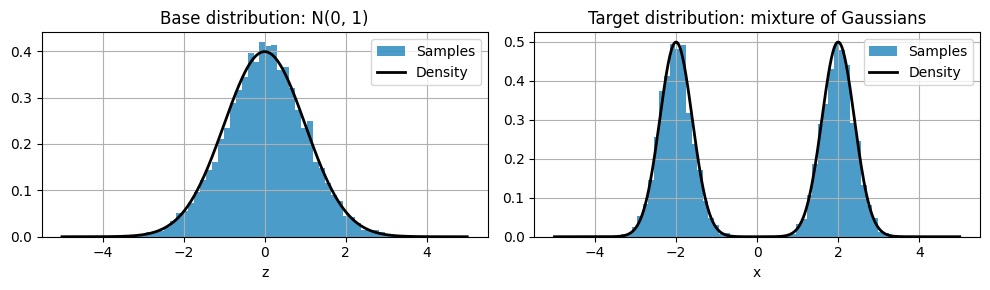

In [2]:
# Target: mixture of two Gaussians
def sample_target(n_samples):
    mix = torch.rand(n_samples) < 0.5
    samples = torch.where(
        mix,
        torch.randn(n_samples) * 0.4 - 2.0,
        torch.randn(n_samples) * 0.4 + 2.0
    )
    return samples


def target_log_prob(x):
    # Log probability of the mixture
    log_p1 = Normal(-2.0, 0.4).log_prob(x)
    log_p2 = Normal(2.0, 0.4).log_prob(x)
    return torch.logsumexp(torch.stack([log_p1, log_p2]) - math.log(2), dim=0)


# Generate samples
target_samples = sample_target(5000)
base_samples = torch.randn(5000)

# Visualize
x_grid = torch.linspace(-5, 5, 500)
target_density = torch.exp(target_log_prob(x_grid))
base_density = torch.exp(Normal(0, 1).log_prob(x_grid))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(base_samples.numpy(), bins=50, density=True, alpha=0.7, label='Samples')
axes[0].plot(x_grid, base_density, 'k-', lw=2, label='Density')
axes[0].set_title('Base distribution: N(0, 1)')
axes[0].set_xlabel('z')
axes[0].legend()

axes[1].hist(target_samples.numpy(), bins=50, density=True, alpha=0.7, label='Samples')
axes[1].plot(x_grid, target_density, 'k-', lw=2, label='Density')
axes[1].set_title('Target distribution: mixture of Gaussians')
axes[1].set_xlabel('x')
axes[1].legend()
plt.tight_layout()
plt.show()

The question: can we learn a function $f$ such that if $z \sim \mathcal{N}(0,1)$, then $x = f(z)$ follows our target distribution?

This is the core idea behind normalizing flows. But we need two things:
1. The function $f$ must be invertible (so we can compute likelihood)
2. We need to track how the density changes under $f$ (the Jacobian)

## Segment 2 - The change of variables formula

Let's start with the simplest possible transformation: a linear scaling $x = az$ where $a > 0$.

If $z$ has density $p_z(z)$, what is the density of $x$? Consider a small interval $[z, z + dz]$ with probability mass $p_z(z)dz$. This maps to $[az, az + adz]$, so the same mass is now spread over an interval of width $adz$. Therefore:

$$p_x(x) = p_z(z) \cdot \frac{1}{|a|} = p_z(f^{-1}(x)) \cdot \left|\frac{df^{-1}}{dx}\right|$$

Taking logs and using $\frac{df^{-1}}{dx} = 1/\frac{df}{dz}$:

$$\log p_x(x) = \log p_z(z) - \log\left|\frac{df}{dz}\right|$$

The term $\log|df/dz|$ accounts for how much the transformation stretches or compresses space.

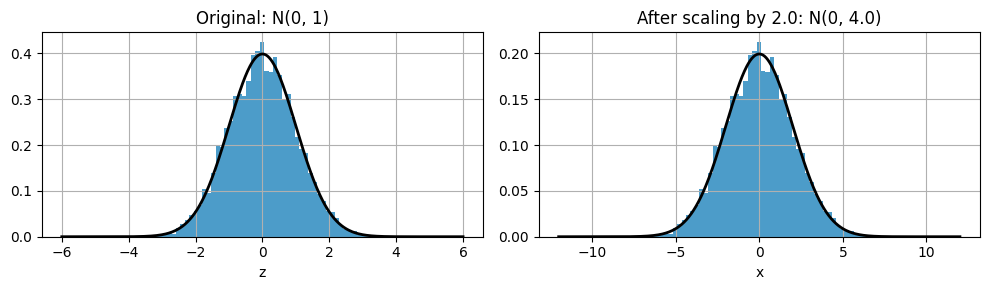

Log-det Jacobian: log|2.0| = 0.693


In [3]:
# Demonstrate change of variables with simple scaling
a = 2.0  # Scaling factor

z = torch.randn(5000)
x = a * z  # Transform

# Compute transformed density using change of variables
z_grid = torch.linspace(-6, 6, 500)
x_grid = a * z_grid

# Original density at z
p_z = torch.exp(Normal(0, 1).log_prob(z_grid))
# Transformed density: p_x(x) = p_z(x/a) / |a|
p_x = p_z / abs(a)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(z.numpy(), bins=50, density=True, alpha=0.7)
axes[0].plot(z_grid, p_z, 'k-', lw=2)
axes[0].set_title('Original: N(0, 1)')
axes[0].set_xlabel('z')

axes[1].hist(x.numpy(), bins=50, density=True, alpha=0.7)
axes[1].plot(x_grid, p_x, 'k-', lw=2)
axes[1].set_title(f'After scaling by {a}: N(0, {a**2})')
axes[1].set_xlabel('x')
plt.tight_layout()
plt.show()

print(f'Log-det Jacobian: log|{a}| = {math.log(abs(a)):.3f}')

### Multivariate case

For $\mathbf{z} \in \mathbb{R}^D$, the derivative becomes a Jacobian matrix $\mathbf{J} = \partial f / \partial \mathbf{z}$, and we need its determinant:

$$\log p_x(\mathbf{x}) = \log p_z(\mathbf{z}) - \log\left|\det\left(\frac{\partial f}{\partial \mathbf{z}}\right)\right|$$

Computing this determinant costs $O(D^3)$, which becomes prohibitive for high dimensions. Traditional normalizing flows (RealNVP, Glow) design special architectures with triangular Jacobians to make this cheap. CNFs take a different approach.

## Segment 3 - From discrete to continuous: the key insight

Traditional flows stack $K$ discrete transformation layers:

$$\mathbf{x} = f_K \circ f_{K-1} \circ \cdots \circ f_1(\mathbf{z})$$

The log-determinant adds up:

$$\log p_x(\mathbf{x}) = \log p_z(\mathbf{z}) - \sum_{k=1}^{K} \log\left|\det\left(\frac{\partial f_k}{\partial \mathbf{z}_{k-1}}\right)\right|$$

Now imagine each layer is a small perturbation: $f_k(\mathbf{z}) = \mathbf{z} + \epsilon \cdot g(\mathbf{z})$ for small $\epsilon$. As we take more layers ($K \to \infty$) with smaller steps ($\epsilon \to 0$), we approach the continuous limit:

$$\frac{d\mathbf{z}}{dt} = f(\mathbf{z}(t), t)$$

This is an ordinary differential equation! The transformation from $\mathbf{z}(0)$ to $\mathbf{z}(1)$ is governed by integrating this ODE. This is a Continuous Normalizing Flow (CNF).

### The instantaneous change of variables

The key result (Chen et al., 2018): if $\mathbf{z}(t)$ evolves according to $d\mathbf{z}/dt = f(\mathbf{z}, t)$, then the log-density evolves as:

$$\frac{d \log p(\mathbf{z}(t))}{dt} = -\text{Tr}\left(\frac{\partial f}{\partial \mathbf{z}}\right)$$

Instead of computing a determinant, we only need the **trace** of the Jacobian. This is simpler but still costs $O(D^2)$ to compute exactly (we need all diagonal elements).

Let's verify this formula on a simple example: a 2D rotation.

Trace of Jacobian: 0.000
Rotation preserves volume (log-det = 0)


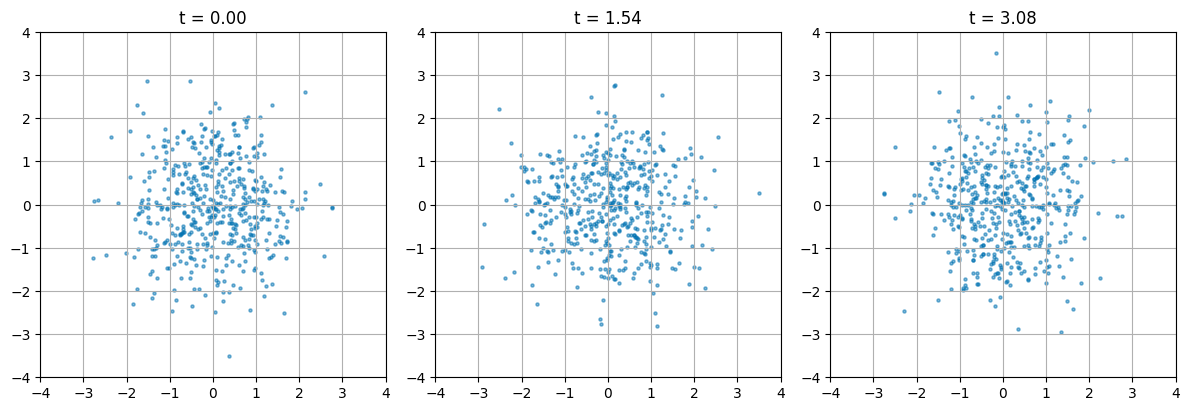

In [4]:

# 2D rotation as a simple CNF
# dz/dt = A @ z where A is antisymmetric (rotation)
omega = 1.0  # Angular velocity
A = torch.tensor([[0.0, -omega], [omega, 0.0]], device=device)


def rotation_field(t, z):
    return z @ A.T


# Trace of Jacobian is trace(A) = 0 for rotation
print(f'Trace of Jacobian: {A.trace().item():.3f}')
print('Rotation preserves volume (log-det = 0)')

# Visualize the flow
n_points = 500
z0 = torch.randn(n_points, 2, device=device)
t_span = torch.linspace(0, 2 * math.pi, 50, device=device)

trajectory = odeint_fn(rotation_field, z0, t_span, **ode_kwargs).cpu()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, t_idx in enumerate([0, 12, 24]):
    axes[i].scatter(trajectory[t_idx, :, 0], trajectory[t_idx, :, 1], alpha=0.5, s=5)
    axes[i].set_xlim(-4, 4)
    axes[i].set_ylim(-4, 4)
    axes[i].set_title(f't = {t_span[t_idx].item():.2f}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()


The rotation preserves the Gaussian shape because its Jacobian has zero trace. A useful CNF needs a vector field $f$ whose trace can change based on where we are in space.

## Segment 4 - Computing the trace efficiently: Hutchinson's estimator

The trace of a $D \times D$ matrix $\mathbf{A}$ can be computed exactly as $\sum_i A_{ii}$, but this requires $D$ evaluations of the network. Hutchinson (1989) showed that for any random vector $\boldsymbol{\epsilon}$ with $\mathbb{E}[\boldsymbol{\epsilon}] = \mathbf{0}$ and $\text{Cov}(\boldsymbol{\epsilon}) = \mathbf{I}$:

$$\text{Tr}(\mathbf{A}) = \mathbb{E}\left[\boldsymbol{\epsilon}^T \mathbf{A} \boldsymbol{\epsilon}\right]$$

The beauty of this: $\boldsymbol{\epsilon}^T \mathbf{A} \boldsymbol{\epsilon} = \boldsymbol{\epsilon}^T (\mathbf{A} \boldsymbol{\epsilon})$, and computing $\mathbf{A}\boldsymbol{\epsilon}$ is just a vector-Jacobian product (VJP), which automatic differentiation does efficiently in $O(D)$ time!

In [5]:

# Demonstrate Hutchinson's trace estimator
D = 10
A = torch.randn(D, D, device=device)
exact_trace = A.trace().item()

# Estimate trace using random vectors
n_estimates = [1, 10, 100, 1000]
for n in n_estimates:
    epsilon = torch.randn(n, D, device=device)
    # eps^T A eps for each sample
    estimates = (epsilon * (epsilon @ A.T)).sum(dim=1)
    est_mean = estimates.mean().item()
    est_std = estimates.std().item() / math.sqrt(n)
    print(f'n={n:4d}: estimate = {est_mean:7.3f} +/- {est_std:.3f} (true = {exact_trace:.3f})')


n=   1: estimate =  -7.527 +/- nan (true = -0.099)
n=  10: estimate =   1.189 +/- 2.693 (true = -0.099)
n= 100: estimate =  -0.937 +/- 0.883 (true = -0.099)
n=1000: estimate =   0.183 +/- 0.334 (true = -0.099)


/var/folders/w8/xz590jyd7r36zmxcspgzj3z40000gn/T/ipykernel_14696/2475192988.py:13: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  est_std = estimates.std().item() / math.sqrt(n)


In [6]:

def hutchinson_trace(f, z, n_samples=1):
    """Estimate trace of Jacobian df/dz using Hutchinson's method."""
    with torch.enable_grad():
        z = z.requires_grad_(True)
        f_z = f(z)

        traces = []
        for _ in range(n_samples):
            epsilon = torch.randn_like(z)
            # Compute epsilon^T @ (df/dz) via VJP
            vjp = torch.autograd.grad(f_z, z, epsilon, create_graph=True)[0]
            trace_est = (epsilon * vjp).sum(dim=-1)
            traces.append(trace_est)

        return f_z, torch.stack(traces).mean(dim=0)


# Test on a simple nonlinear function
def test_fn(z):
    return torch.stack([z[:, 0]**2 + z[:, 1], z[:, 0] * z[:, 1]], dim=1)


z_test = torch.tensor([[1.0, 2.0], [3.0, 4.0]], device=device)
f_z, trace_est = hutchinson_trace(test_fn, z_test, n_samples=1000)

# Exact trace: d(z0^2 + z1)/dz0 + d(z0*z1)/dz1 = 2*z0 + z0 = 3*z0
exact_traces = 3 * z_test[:, 0]
print(f'Estimated traces: {trace_est.detach().cpu().numpy()}')
print(f'Exact traces:     {exact_traces.detach().cpu().numpy()}')


Estimated traces: [2.7792063 9.436569 ]
Exact traces:     [3. 9.]


## Segment 5 - Building a CNF from scratch

Now we have all the pieces. A CNF consists of:
1. A neural network $f_\theta(\mathbf{z}, t)$ defining the vector field
2. An ODE solver to integrate the dynamics
3. Hutchinson's estimator for the log-density change

We solve two ODEs simultaneously:
- $d\mathbf{z}/dt = f_\theta(\mathbf{z}, t)$ (sample trajectory)
- $d\log p/dt = -\text{Tr}(\partial f_\theta / \partial \mathbf{z})$ (density change)

Let's build this for our 1D mixture problem.

In [7]:

class VectorField(nn.Module):
    """Neural network defining dz/dt = f(z, t)."""
    def __init__(self, dim, hidden_dim=64):
        super().__init__()
        # Include time as input
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, t, z):
        # Concatenate time to input
        if z.ndim == 1:
            z = z.unsqueeze(0)
        t_vec = t.expand(z.shape[0], 1) if t.ndim == 0 else t
        t_vec = t_vec.to(z)
        tz = torch.cat([t_vec, z], dim=-1)
        return self.net(tz)


class CNF(nn.Module):
    """Continuous Normalizing Flow."""
    def __init__(self, dim, hidden_dim=64):
        super().__init__()
        self.dim = dim
        self.vector_field = VectorField(dim, hidden_dim)
        # Buffers keep the base distribution on the same device as the model
        self.register_buffer('base_mean', torch.zeros(dim))
        self.register_buffer('base_std', torch.ones(dim))

    def _base_log_prob(self, z):
        base_dist = Normal(self.base_mean, self.base_std)
        return base_dist.log_prob(z).sum(dim=-1)

    def _augmented_dynamics(self, t, states):
        """Joint dynamics for z and log_p."""
        z, log_p = states

        with torch.enable_grad():
            z = z.requires_grad_(True)
            f_z = self.vector_field(t, z)

            # Hutchinson trace estimator
            epsilon = torch.randn_like(z)
            vjp = torch.autograd.grad(f_z, z, epsilon, create_graph=True)[0]
            trace = (epsilon * vjp).sum(dim=-1)

        return f_z, -trace

    def forward(self, z0):
        """Transform z0 -> z1 and compute log probability."""
        if z0.ndim == 1:
            z0 = z0.unsqueeze(-1)

        log_p0 = self._base_log_prob(z0)
        t_span = torch.tensor([0.0, 1.0], device=z0.device, dtype=z0.dtype)

        z_t, log_p_t = odeint_fn(self._augmented_dynamics, (z0, log_p0), t_span, **ode_kwargs)

        return z_t[-1], log_p_t[-1]

    def log_prob(self, x):
        """Compute log p(x) by integrating backward."""
        if x.ndim == 1:
            x = x.unsqueeze(-1)

        log_p1 = torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
        t_span = torch.tensor([1.0, 0.0], device=x.device, dtype=x.dtype)

        z_t, log_p_t = odeint_fn(self._augmented_dynamics, (x, log_p1), t_span, **ode_kwargs)
        z0 = z_t[-1]
        delta_log_p = log_p_t[-1]

        log_p_base = self._base_log_prob(z0)
        return log_p_base - delta_log_p

    def sample(self, n_samples):
        """Generate samples by integrating forward from base."""
        z0 = torch.randn(n_samples, self.dim, device=self.base_mean.device, dtype=self.base_mean.dtype)
        with torch.no_grad():
            z1, _ = self.forward(z0)
        return z1


### Training on the 1D mixture

We maximize the log-likelihood of the target samples under our model. This is equivalent to minimizing the KL divergence from the data distribution to our model.

In [ ]:

# Create model and optimizer
cnf_1d = CNF(dim=1, hidden_dim=64).to(device)
optimizer = optim.Adam(cnf_1d.parameters(), lr=1e-3)

# Training data
train_data = sample_target(2000).to(device)

# Training loop
losses = []
n_epochs = 800
batch_size = 256


if device.type == 'cuda':
    torch.cuda.empty_cache()
elif device.type == 'mps' and hasattr(torch, 'mps'):
    torch.mps.empty_cache()

for epoch in range(1, n_epochs + 1):
    idx = torch.randint(0, len(train_data), (batch_size,))
    batch = train_data[idx].unsqueeze(-1)

    log_prob = cnf_1d.log_prob(batch)
    loss = -log_prob.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 200 == 0:
        print(f'Epoch {epoch}, NLL: {loss.item():.3f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses)
ax.set_xlabel('Iteration')
ax.set_ylabel('Negative log-likelihood')
ax.set_title('CNF training on 1D mixture')
plt.show()


In [ ]:
# Generate samples and compare
with torch.no_grad():
    generated = cnf_1d.sample(5000).cpu().squeeze()

# Compute learned density
x_grid = torch.linspace(-5, 5, 200).to(device)
with torch.no_grad():
    log_p = cnf_1d.log_prob(x_grid.unsqueeze(-1))
    learned_density = torch.exp(log_p).cpu()

target_density = torch.exp(target_log_prob(x_grid.cpu()))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(generated.numpy(), bins=50, density=True, alpha=0.7, label='CNF samples')
axes[0].hist(target_samples.numpy(), bins=50, density=True, alpha=0.5, label='Target samples')
axes[0].set_xlabel('x')
axes[0].set_title('Sample comparison')
axes[0].legend()

axes[1].plot(x_grid.cpu(), target_density, 'k-', lw=2, label='Target')
axes[1].plot(x_grid.cpu(), learned_density, 'C1--', lw=2, label='CNF')
axes[1].set_xlabel('x')
axes[1].set_title('Density comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

### Visualizing the flow

One advantage of CNFs: we can visualize how samples evolve from base to target.

In [ ]:

# Track trajectories through time
n_traj = 500
z0 = torch.randn(n_traj, 1, device=device)
t_span = torch.linspace(0, 1, 50, device=device)

with torch.no_grad():
    # Just integrate the dynamics (not the log-prob)
    trajectories = odeint_fn(
        lambda t, z: cnf_1d.vector_field(t, z),
        z0, t_span,
        **ode_kwargs
    ).cpu().squeeze(-1)

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(0, n_traj, 5):
    ax.plot(t_span.cpu(), trajectories[:, i], alpha=0.3, lw=0.5)

ax.set_xlabel('t')
ax.set_ylabel('z(t)')
ax.set_title('Sample trajectories: Gaussian to mixture')
plt.show()


## Segment 6 - 2D example: the moons dataset

Let's scale up to 2D. The two-moons dataset is a standard benchmark because it requires the flow to learn a nonlinear, non-convex transformation.

In [ ]:
def two_moons(n_samples, noise=0.05):
    n_half = n_samples // 2
    angles = torch.rand(n_half) * math.pi
    upper = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)
    lower = torch.stack([1.0 - torch.cos(angles), -torch.sin(angles) - 0.5], dim=1)
    data = torch.cat([upper, lower], dim=0)
    data += noise * torch.randn_like(data)
    return data


moons_data = two_moons(4000).to(device)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(moons_data[:, 0].cpu(), moons_data[:, 1].cpu(), alpha=0.3, s=5)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Two moons dataset')
ax.set_aspect('equal')
plt.show()

In [ ]:

# Train 2D CNF
cnf_2d = CNF(dim=2, hidden_dim=64).to(device)
optimizer = optim.Adam(cnf_2d.parameters(), lr=1e-3)

losses_2d = []
n_epochs = 1000
batch_size = 256


if device.type == 'cuda':
    torch.cuda.empty_cache()
elif device.type == 'mps' and hasattr(torch, 'mps'):
    torch.mps.empty_cache()

for epoch in range(1, n_epochs + 1):
    idx = torch.randint(0, len(moons_data), (batch_size,))
    batch = moons_data[idx]

    log_prob = cnf_2d.log_prob(batch)
    loss = -log_prob.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_2d.append(loss.item())

    if epoch % 200 == 0:
        print(f'Epoch {epoch}, NLL: {loss.item():.3f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses_2d)
ax.set_xlabel('Iteration')
ax.set_ylabel('Negative log-likelihood')
ax.set_title('CNF training on two moons')
plt.show()


In [ ]:
# Compare samples
with torch.no_grad():
    generated_2d = cnf_2d.sample(2000).cpu()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(moons_data[:, 0].cpu(), moons_data[:, 1].cpu(), alpha=0.3, s=5)
axes[0].set_title('Data')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].set_aspect('equal')

axes[1].scatter(generated_2d[:, 0], generated_2d[:, 1], alpha=0.3, s=5, color='C1')
axes[1].set_title('CNF samples')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:

# Visualize the flow transformation
n_viz = 300
z0_viz = torch.randn(n_viz, 2, device=device)
t_span = torch.linspace(0, 1, 6, device=device)

with torch.no_grad():
    traj_2d = odeint_fn(
        lambda t, z: cnf_2d.vector_field(t, z),
        z0_viz, t_span,
        **ode_kwargs
    ).cpu()

fig, axes = plt.subplots(1, 6, figsize=(15, 2.5))
for i, ax in enumerate(axes):
    ax.scatter(traj_2d[i, :, 0], traj_2d[i, :, 1], alpha=0.5, s=10)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-2, 2)
    ax.set_title(f't = {t_span[i].item():.2f}')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## Segment 7 - SciML application: learning output distributions from physics

Here's where CNFs become powerful for scientific computing. Consider a damped oscillator with uncertain parameters. Given measurements, we want to characterize the distribution of the system's response.

The setup:
1. Parameters $\theta = (\zeta, \omega_n)$ are drawn from a prior
2. For each $\theta$, we simulate the oscillator and extract features (e.g., peak amplitude, settling time)
3. We train a CNF to model the distribution of these features

This is uncertainty quantification: the CNF captures how parameter uncertainty propagates to output uncertainty.

In [ ]:

def damped_oscillator_rhs(t, state, zeta, omega_n):
    x, v = state[..., 0], state[..., 1]
    dxdt = v
    dvdt = -2 * zeta * omega_n * v - omega_n**2 * x
    return torch.stack([dxdt, dvdt], dim=-1)


def simulate_oscillator(zeta, omega_n, t_eval):
    """Simulate oscillator and return trajectory."""
    y0 = torch.tensor([1.0, 0.0], device=zeta.device, dtype=zeta.dtype)  # Initial displacement, zero velocity
    t_eval = t_eval.to(zeta)
    sol = odeint_fn(
        lambda t, y: damped_oscillator_rhs(t, y, zeta, omega_n),
        y0, t_eval,
        **ode_kwargs
    )
    return sol[:, 0]  # Return displacement


def extract_features(trajectory, t_eval):
    """Extract features: peak amplitude and approximate settling time."""
    peak_amp = trajectory.abs().max()

    # Settling time: when |x| stays below 5% of initial
    threshold = 0.05
    below_threshold = (trajectory.abs() < threshold).float()
    if below_threshold.sum() > 0:
        # Find first crossing
        settling_idx = (below_threshold.cumsum(0) > 0).float().argmax()
        settling_time = t_eval[settling_idx]
    else:
        settling_time = t_eval[-1]

    return torch.stack([peak_amp, settling_time])


In [ ]:
# Generate dataset: sample parameters, simulate, extract features
n_samples = 3000
t_eval = torch.linspace(0, 10, 200)

# Prior on parameters
zeta_samples = torch.rand(n_samples) * 0.3 + 0.05  # Uniform(0.05, 0.35)
omega_samples = torch.rand(n_samples) * 1.0 + 0.5   # Uniform(0.5, 1.5)

features = []
for i in range(n_samples):
    traj = simulate_oscillator(zeta_samples[i], omega_samples[i], t_eval)
    feat = extract_features(traj, t_eval)
    features.append(feat)

features = torch.stack(features)
print(f'Feature shape: {features.shape}')
print(f'Peak amplitude range: [{features[:, 0].min():.2f}, {features[:, 0].max():.2f}]')
print(f'Settling time range: [{features[:, 1].min():.2f}, {features[:, 1].max():.2f}]')

In [ ]:
# Visualize the feature distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].scatter(zeta_samples, omega_samples, alpha=0.3, s=5)
axes[0].set_xlabel('Damping ratio $\\zeta$')
axes[0].set_ylabel('Natural frequency $\\omega_n$')
axes[0].set_title('Parameter samples')

axes[1].hist(features[:, 0].numpy(), bins=50, density=True, alpha=0.7)
axes[1].set_xlabel('Peak amplitude')
axes[1].set_title('Peak amplitude distribution')

axes[2].scatter(features[:, 0], features[:, 1], alpha=0.3, s=5)
axes[2].set_xlabel('Peak amplitude')
axes[2].set_ylabel('Settling time [s]')
axes[2].set_title('Joint feature distribution')

plt.tight_layout()
plt.show()

In [ ]:

# Normalize features for better training
feat_mean = features.mean(dim=0)
feat_std = features.std(dim=0)
features_norm = (features - feat_mean) / feat_std
features_norm = features_norm.to(device)

# Train CNF on features
cnf_uq = CNF(dim=2, hidden_dim=64).to(device)
optimizer = optim.Adam(cnf_uq.parameters(), lr=1e-3)

losses_uq = []
n_epochs = 1000
batch_size = 256


if device.type == 'cuda':
    torch.cuda.empty_cache()
elif device.type == 'mps' and hasattr(torch, 'mps'):
    torch.mps.empty_cache()

for epoch in range(1, n_epochs + 1):
    idx = torch.randint(0, len(features_norm), (batch_size,))
    batch = features_norm[idx]

    log_prob = cnf_uq.log_prob(batch)
    loss = -log_prob.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_uq.append(loss.item())

    if epoch % 200 == 0:
        print(f'Epoch {epoch}, NLL: {loss.item():.3f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses_uq)
ax.set_xlabel('Iteration')
ax.set_ylabel('Negative log-likelihood')
ax.set_title('CNF for uncertainty quantification')
plt.show()


In [ ]:
# Generate samples and transform back to original scale
with torch.no_grad():
    generated_norm = cnf_uq.sample(2000).cpu()
    generated_feat = generated_norm * feat_std + feat_mean

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(features[:, 0], features[:, 1], alpha=0.3, s=5, label='Data')
axes[0].set_xlabel('Peak amplitude')
axes[0].set_ylabel('Settling time [s]')
axes[0].set_title('True feature distribution')

axes[1].scatter(generated_feat[:, 0], generated_feat[:, 1], alpha=0.3, s=5, color='C1', label='CNF')
axes[1].set_xlabel('Peak amplitude')
axes[1].set_ylabel('Settling time [s]')
axes[1].set_title('CNF-generated distribution')

plt.tight_layout()
plt.show()

### Computing probabilities and quantiles

With a trained CNF, we can answer questions like:
- What is the probability that the settling time exceeds 5 seconds?
- What is the 95th percentile of peak amplitude?

These are computed by sampling from the learned distribution.

In [ ]:
# Generate many samples for statistics
with torch.no_grad():
    samples_norm = cnf_uq.sample(10000).cpu()
    samples = samples_norm * feat_std + feat_mean

# P(settling time > 5)
prob_slow = (samples[:, 1] > 5).float().mean()
print(f'P(settling time > 5s): {prob_slow:.3f}')

# Quantiles of peak amplitude
quantiles = torch.tensor([0.05, 0.5, 0.95])
peak_quantiles = torch.quantile(samples[:, 0], quantiles)
print(f'Peak amplitude quantiles [5%, 50%, 95%]: {peak_quantiles.numpy()}')

# Visualize marginals with quantiles
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(samples[:, 0].numpy(), bins=50, density=True, alpha=0.7)
for q, val in zip(quantiles, peak_quantiles):
    axes[0].axvline(val, color='red', linestyle='--', lw=1)
axes[0].set_xlabel('Peak amplitude')
axes[0].set_title('Peak amplitude with 5/50/95% quantiles')

axes[1].hist(samples[:, 1].numpy(), bins=50, density=True, alpha=0.7)
axes[1].axvline(5.0, color='red', linestyle='--', lw=2, label='5s threshold')
axes[1].set_xlabel('Settling time [s]')
axes[1].set_title(f'Settling time (P(>5s) = {prob_slow:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

## Key takeaways

1. **Normalizing flows** transform simple distributions into complex ones while tracking density changes via the Jacobian determinant.

2. **Continuous normalizing flows** replace discrete transformation layers with an ODE, converting the determinant into a trace integral.

3. **Hutchinson's estimator** makes trace computation efficient: $O(D)$ instead of $O(D^2)$, enabling CNFs to scale.

4. **CNFs for SciML**: by modeling output distributions, CNFs enable uncertainty quantification, probabilistic prediction, and risk assessment in engineering systems.

## Exercises

1. Modify the 1D CNF to use multiple Hutchinson samples per step and observe variance reduction.

2. Train the 2D CNF on a harder distribution (e.g., a spiral) and visualize the transformation.

3. In the oscillator example, condition the CNF on observed peak amplitude and sample the conditional distribution of settling time.

4. Replace the MLP vector field with a time-dependent architecture and compare training dynamics.

5. Implement flow matching as an alternative to maximum likelihood training and compare convergence speed.